# Flash Attention - V2

$Q, K, V$

$S = Q K^T $

$C = P V^T$

reuse KV cache through 4 Q

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from helper import plot
from fa import flash_attention, flash_attention_vanilla, flash_decode , _array_matmul, _balanced_split
from tile_model import Hardware, DMA, VCPU, SA1, SA2
from analytical_model import analytical


## 0. Smooth Quantization & Int8 -> Int16 stability

Before moving on to the implementation, there are two important quantization and overflow providing should be provided:

1. W8A16 outlier

Original LlaMA 8B is a BF16 model, while running on this architecture have to be W8A16. A quantization should be explicitly
designed for rounding.

Ref:  SageAttention2: Efficient Attention with Thorough Outlier Smoothing and Per-thread INT4 Quantization

2. Overflow Int8 -> Int16

For activation, Int 16 and Int8 are used and **radix-16 digit decomposition** has been applied for numerical accumulator stability

$A = A_0 + 16A_1, B = B_0 + 16B_1$

$AB = A_0 B_0 + 16A_0 B_1 + 16 A_1 B_0 + 256 A_1 B_1$

ref: BISMO: A Scalable Bit-Serial Matrix Multiplication Overlay for Reconfigurable Computing



## 1. Prefill

First take sequential flash attention as the benchmark. This implementation follows Algorithm 1 of FlashAttention-2 directly: all QK and PV products run on the SA units, while the remaining non-GEMM operations run on the VCPU.

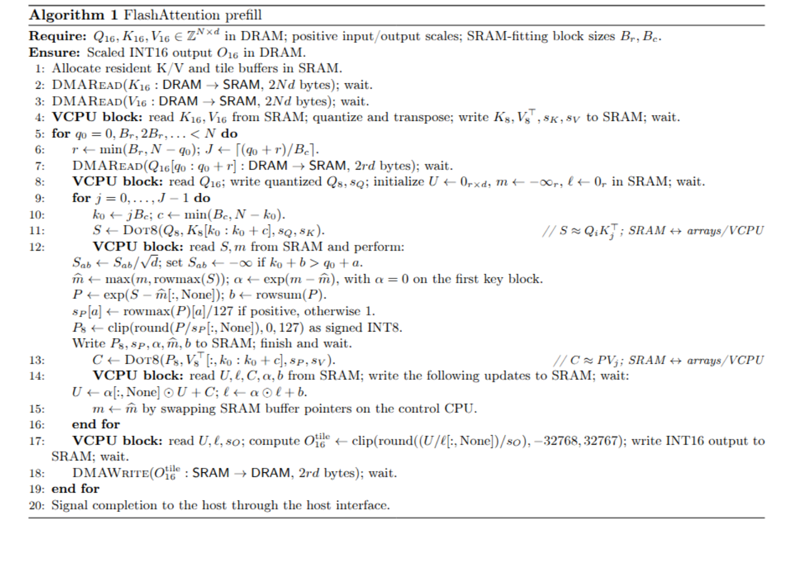

In [2]:
plot("img/fa2_prefill.png", 800)

### Find the best Br Bc to minimize the overhead

The choice of Br and Bc can be formulated as an optimization problem:

$$S = Q K^T$$
$$C = P V$$

$$\min T(B_r, Bc)_{B_r, B_c} s.t. M_{SRAM}(B_r, B_c) <= 16MB$$

For concur such problem, the review of theoretical performance on SA1/SA2 in the previous section is needed:

#### Bandwidth model


1. sa2 has no advantage on K = 128, and a 2x advantage on k = 256.

2. K >= 128 Memory bound, <= computation bound

3. when K = 128, sa1 complete same macs in the same cycle (128)

**suggest: QK: K = 128, both row_size = 32n**

-> Br1 = Br2 = Br / 2

-> Br can be divisible by 32 and ideally // 2048

-> Br in {64, 128, 192, 256 512...}

suggest PV: reduction in Bc, should be overflow safe avoids a short final reduction chunk in PV

**-> Bc in {128, 256, 512 ...}**

#### MAC model

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:128
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:256
    sa2 macs: 131072, cycle:256

**suggest: QK: K = 128, 1:1

suggest: PV: K =256, row_size**
SA1/SA2 both reach peak intensity when K=256

## Gantt plot for fa2

The gantt schedule for vanilla fa2 is shown as:

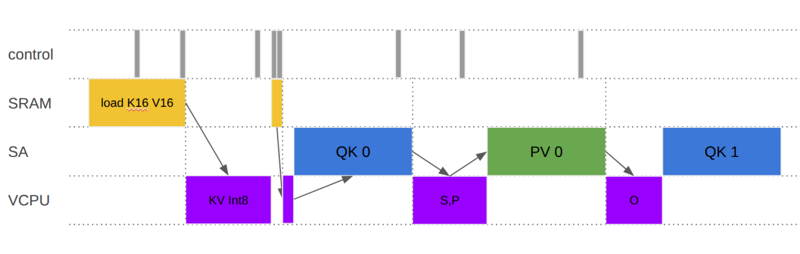

In [3]:
plot("img/fa2_schedule.png", 800)

Performance analysis:

In [4]:
# Performance analysis for vanilla fa2

T=2048
S=2048
H=128
G=4

flash_attention_vanilla(T=T,
                        S=S,
                        H=H,
                        G=G,
                        Br=128,
                        Bc=256,
                        R=128,
                        causal=True,
                        hw=Hardware(),
                        verbose=False)

{'cycles': 13967693,
 'time_ms': 13.967692999999999,
 'busy': {'DMA': 130720, 'VCPU': 3072685, 'SA': 10764288},
 'peak_sram_bytes': 1572872,
 'sram_utilization_percent': 9.37504768371582}

## Schedule Bubble:

Looking at the Gantt chart, there are two kinds of scheduling bubbles. Those outlined in green: while the SA is busy the VCPU sits idle,
 and while the VCPU is busy the SA sits idle.
 Those outlined in red: scheduling blocks with no dependency between them could be computed in parallel instead of waiting on one another.

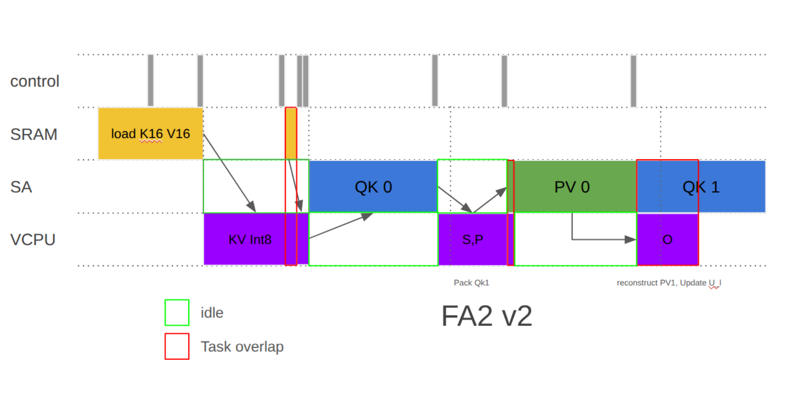

In [5]:
plot("img/schedule_bubble.png", 800)

### Solution: Finer Granularity

In fact, the task dependencies in FA2 can be decomposed at a finer granularity to reduce both kinds of bubbles. The SA-VCPU idling in particular can be addressed by a more fine-grained online softmax.

The online softmax from the FA2 paper is as follows:

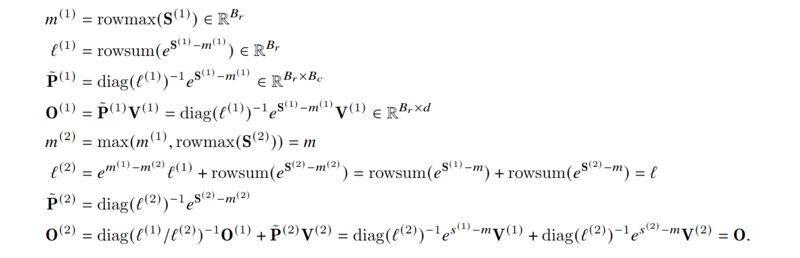

In [6]:
plot("img/online_softmax.png", 800)

Taking these as the new atomic tasks, rebuild the dependency graph:

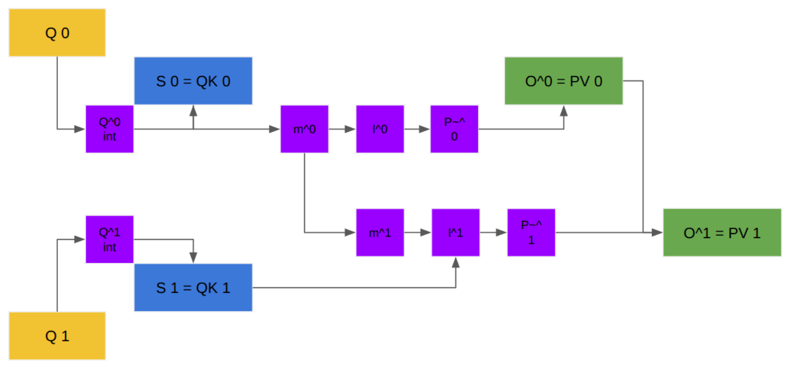

In [7]:
plot("img/schedule_dependency.png", 800)

Reordering these tasks according to their dependencies, we obtain:

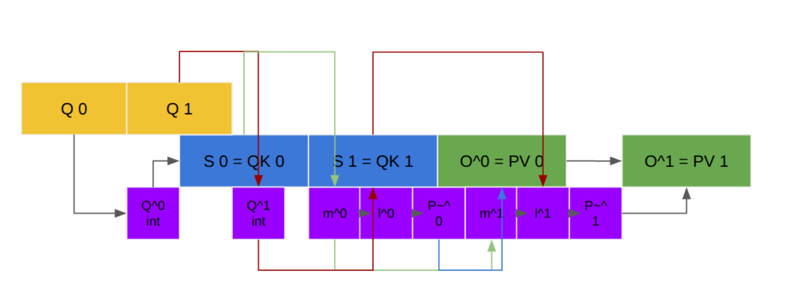

In [8]:
plot("img/schedule_pipeline.png", 800)

The diagram above can be written as the following pseudocode:

    DMA load K16, V16: DRAM → SRAM
    VCPU quantize K16, V16 → K8, V8T; write scales to SRAM
    SRAM release K16, V16 after conversion

    FOR each grouped Q head
        FOR each query tile Qi
            DMA load Qi16: DRAM → SRAM
            VCPU quantize Qi16 → Qi8
            VCPU initialize U = 0, l = 0, m = -infinity
            SRAM release Qi16

            VCPU pack QK operands for blocks 0, 1, 2, if present
            SA1 & SA2 queue QK(0), QK(1), if present

            FOR p = 0 ... last key block
                SA1 & SA2 queue QK(p + 2), if present

                VCPU read QK(p) raw results from SRAM
                VCPU reconstruct and scale scores S
                VCPU apply causal mask

                VCPU compute:
                    m_new = maximum(m, rowmax(S))
                    alpha[p] = exp(m - m_new)
                    P = exp(S - m_new)
                    l = alpha[p] * l + rowsum(P)
                    m = m_new

                VCPU write updated m, l and alpha[p] to SRAM
                VCPU quantize P → P8
                VCPU pack P8, V8T for PV(p)

                VCPU pack QK(p + 3) operands, if present
                SA1 & SA2 queue PV(p); write raw results to SRAM

                IF p >= 1
                    VCPU reconstruct and scale PV(p - 1) → C
                    VCPU read U, C, alpha[p - 1]
                    VCPU write U = alpha[p - 1] * U + C
                    SRAM release consumed block buffers
                END IF
            END FOR

            VCPU reconstruct and scale the final PV → C
            VCPU write U = alpha[last] * U + C

            VCPU normalize O = U / l
            VCPU encode O16 and write to SRAM
            DMA store O16: SRAM → DRAM
            CPU wait for store completion
            SRAM release query-tile buffers
        END FOR
    END FOR

    SRAM release K8, V8T and scales

In [9]:
# result = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False)
# print("total cycle:   ", result["cycles"])
# print("total ms:   ", round(result["time_ms"], 3))

## 2. Decode

The FA algorithm during decode is almost identical to the one used during prefill. In decode, 4 Q share 1 KV. Every cached key is visible to the G query heads. The keys are the array rows, so both arrays share every GEMM. However, Q has a sequence length of only 1, so even after merging four Q's, the two SAs still cannot be fully saturated. The strategy is therefore:

Q: B × G × 1 × H = 16 x 4 x 1 x 128

K,V: B × 1 × S × H = 16 x 1 x 2048 x 128

$$S = QK^T -> S^T = K Q^T$$

The transported size: 4 x 128, 128 x 256 (Bc) -> 256 (Bc) x 128, 128 x 4

Let's do a performance check:

In [10]:
from fa import flash_attention, flash_decode

for Bc in (256, 512, 1024, 2048):
    qk = flash_attention(T=G, S=S, H=H, G=1, Br=G, Bc=Bc, R=256, causal=False, verbose=False)
    kq = flash_decode(S=S, H=H, G=G, Bc=Bc, R=256, verbose=False)
    for name, job in (("S   = Q K^T", qk), ("S^T = K Q^T", kq)):
        print(f"Bc={Bc:4d}  {name}: {job['cycles']:6d} cycles, arrays {job['utilization']['SA1+SA2']:.0%}")

Bc= 256  S   = Q K^T:  77374 cycles, arrays 68%
Bc= 256  S^T = K Q^T:  44403 cycles, arrays 49%
Bc= 512  S   = Q K^T:  74715 cycles, arrays 70%
Bc= 512  S^T = K Q^T:  38491 cycles, arrays 53%
Bc=1024  S   = Q K^T:  75547 cycles, arrays 69%
Bc=1024  S^T = K Q^T:  35655 cycles, arrays 54%
Bc=2048  S   = Q K^T:  84257 cycles, arrays 62%
Bc=2048  S^T = K Q^T:  36097 cycles, arrays 52%


    DMA load Q16 (G rows): DRAM → SRAM
    VCPU quantize Q16 → Q8 transposed (H x G)
    VCPU initialize U = 0, l = 0, m = -infinity
    SRAM release Q16

    FOR each key block of the INT8 KV cache
        DMA load K8, V8T block: DRAM → SRAM; prefetch two blocks ahead

        VCPU pack QK operands, keys as rows
        SA1 & SA2 compute S = K8 . Q8; write raw results to SRAM

        VCPU reconstruct and scale scores S
        VCPU compute:
            m_new = maximum(m, colmax(S))
            alpha = exp(m - m_new)
            P = exp(S - m_new)
            l = alpha * l + colsum(P)
            m = m_new
        VCPU quantize P → P8

        VCPU pack P8, V8T for PV
        SA1 & SA2 compute C = V8T . P8; write raw results to SRAM

        VCPU reconstruct and scale C
        VCPU write U = alpha * U + C
        SRAM release block buffers
    END FOR

    VCPU normalize O = U / l
    VCPU encode O16 and write to SRAM
    DMA store O16: SRAM → DRAM
    SRAM release step buffers

## 3. Performance analysis

Using the prefill and decode attention algorithms described above, we run a grid search to test whether the optimal parameters for the two algorithms align with our analytical results.

In [11]:
hw_bw = Hardware(control="pipelined", array_model="bandwidth")   # same pipelined control as analytical()
hw_mac = Hardware(control="pipelined", array_model="mac")

for R in [64, 128, 256]:
    for Br_SA1 in [16, 32, 64, 128, 256]: # Must be a multiple of 16
        for Br_SA2 in [32, 64, 128, 256]:
            for Bc in  [128, 256, 512]:
                Br = Br_SA1 + Br_SA2                  # query rows per tile: SA1 rows + SA2 rows
                FA2_BW_ms = round(flash_attention(T=T, S=S, H=H, G=G, Br=Br, Br_sa1=Br_SA1, Bc=Bc, R=R,
                                                  hw=hw_bw, verbose=False)["time_ms"], 3)
                FA2_MAC_ms = round(flash_attention(T=T, S=S, H=H, G=G, Br=Br, Br_sa1=Br_SA1, Bc=Bc, R=R,
                                                   hw=hw_mac, verbose=False)["time_ms"], 3)
                print(R, Br_SA1, Br_SA2, Bc, FA2_BW_ms, FA2_MAC_ms)
    print("*"*72)


64 16 32 128 6.888 6.891
64 16 32 256 6.118 6.167
64 16 32 512 6.024 6.052
64 16 64 128 7.181 7.235
64 16 64 256 7.049 7.08
64 16 64 512 6.991 7.008
64 16 128 128 7.923 7.959
64 16 128 256 7.849 7.867
64 16 128 512 7.813 7.823
64 16 256 128 8.226 8.246
64 16 256 256 8.189 8.2
64 16 256 512 8.169 8.175
64 32 32 128 5.827 5.827
64 32 32 256 4.544 4.576
64 32 32 512 4.447 4.467
64 32 64 128 6.136 6.186
64 32 64 256 6.031 6.058
64 32 64 512 5.98 5.995
64 32 128 128 7.075 7.105
64 32 128 256 7.014 7.029
64 32 128 512 6.985 6.994
64 32 256 128 7.906 7.926
64 32 256 256 7.845 7.856
64 32 256 512 7.824 7.83
64 64 32 128 5.997 6.045
64 64 32 256 5.868 5.894
64 64 32 512 5.801 5.816
64 64 64 128 4.604 4.638
64 64 64 256 4.529 4.547
64 64 64 512 4.494 4.505
64 64 128 128 5.863 5.888
64 64 128 256 5.81 5.824
64 64 128 512 5.784 5.792
64 64 256 128 6.871 6.888
64 64 256 256 6.835 6.845
64 64 256 512 6.817 6.822
64 128 32 128 7.134 7.164
64 128 32 256 7.054 7.07
64 128 32 512 7.017 7.026
64 128 64 1

### Best Prefill parameter

The best parameter in Prefill for bandwidth and mac model:

R, Br_SA1, Br_SA2, Bc, FA2_BW_ms, FA2_MAC_ms

  **256 256 256 512 2.316 4.138**

  **256 64 128 512 2.377 3.233**

The grid search result align with our analytical analysis for SA Br selection: bandwidth 1:1, mac 1:2

### Best Decoder setting



In [12]:
hw_bw = Hardware(control="pipelined", array_model="bandwidth")   # same settings as the prefill grid
hw_mac = Hardware(control="pipelined", array_model="mac")

rows = []
for R in [64, 128, 256]:
    for Bc in [128, 256, 512, 1024, 2048]:
        FA2_BW_us = round(flash_decode(S=S, H=H, G=G, Bc=Bc, R=R, hw=hw_bw, verbose=False)["time_us"], 2)
        FA2_MAC_us = round(flash_decode(S=S, H=H, G=G, Bc=Bc, R=R, hw=hw_mac, verbose=False)["time_us"], 2)
        print(R, Bc, FA2_BW_us, FA2_MAC_us)
        rows.append((R, Bc, FA2_BW_us, FA2_MAC_us))
    print("*"*72)

print("R Bc BW_us MAC_us")
print("BW optimal: ", *min(rows, key=lambda r: r[2]))
print("MAC optimal:", *min(rows, key=lambda r: r[3]))

64 128 54.12 55.14
64 256 42.08 42.59
64 512 36.45 36.71
64 1024 34.4 34.53
64 2048 34.91 34.98
************************************************************************
128 128 45.92 52.71
128 256 33.38 38.3
128 512 27.49 31.99
128 1024 25.32 29.35
128 2048 25.76 29.69
************************************************************************
256 128 45.92 52.71
256 256 32.9 38.01
256 512 26.75 31.7
256 1024 24.45 29.06
256 2048 24.83 29.4
************************************************************************
R Bc BW_us MAC_us
BW optimal:  256 1024 24.45 29.06
MAC optimal: 256 1024 24.45 29.06



**The best decode setting:**

R Bc BW_us MAC_us

**BW & MAC optimal:  256 1024 24.45 29.06**

## Check our selected parameter fits into SRAM

KV cache         512.0 KiB

U + Q8           2.5 KiB

peak             566.59375 KiB = 3.46 % of 16 MiB

**The SRAM test pass \o/**

In [16]:
S, H, G = 2048, 128, 4                  # one KV-head group, one decode step
KiB, SRAM = 1024, 16 * 1024**2

cache = 2 * S * H                       # INT8 K + pre-transposed V: the whole context
acc = 4 * H * G + G * H                 # FP32 accumulator U, plus Q8
r = flash_decode(S=S, H=H, G=G, Bc = 1024, verbose=False, gantt_path=None)   # Bc=2048: one block, no streaming
peak = r["peak_sram_bytes"]

print("KV cache        ", cache / KiB, "KiB")
print("U + Q8          ", acc / KiB, "KiB")
print("packed operands ", (peak - cache - acc) / KiB, "KiB   # array-layout copy of K")
print("peak            ", peak / KiB, "KiB =", round(100 * peak / SRAM, 2), "% of 16 MiB")

for s in (2048, 8192, 32768, 131072):   # the cache is what grows with context
    print(f"S={s:6d}  cache {2 * s * H / 2**20:5.1f} MiB", "fits" if 2 * s * H < SRAM else "too big")

KV cache         512.0 KiB
U + Q8           2.5 KiB
packed operands  52.09375 KiB   # array-layout copy of K
peak             566.59375 KiB = 3.46 % of 16 MiB
S=  2048  cache   0.5 MiB fits
S=  8192  cache   2.0 MiB fits
S= 32768  cache   8.0 MiB fits
S=131072  cache  32.0 MiB too big


## Bottleneck analysis

In [14]:

import tile_model
import fa
import sys, dataclasses

def run(label, hw, **kw):
    fa._array_matmul.cache_clear(); fa._balanced_split.cache_clear()
    r = flash_attention(T=2048,S=2048,H=128,G=4,Br=192,Bc=256,Br_sa1=None,R=256,hw=hw,verbose=False,**kw)
    u = r['utilization']
    macs = 4*sum(m*c*128*2 for _ in [0] for m,c in [(192,256)])  # placeholder
    print(f'{label:46s} {r["time_ms"]:7.3f} ms  arrays {100*u["SA1+SA2"]:5.1f}%  vcpu {100*u["VCPU"]:5.1f}%  dma {100*u["DMA"]:4.1f}%')

    return r


base = Hardware()

run('baseline', base)
run('DMA bandwidth x4', dataclasses.replace(base, dma_bw=256))
run('vector bandwidth x2', dataclasses.replace(base, vector_bw=256))
run('vector launch 300 -> 0', dataclasses.replace(base, vector_launch=0))
run('array command latency 100 -> 0', dataclasses.replace(base, array_latency=0))
run('pipelined command issue', dataclasses.replace(base, control='pipelined'))
run('array_model=bandwidth (no MAC limit)', dataclasses.replace(base, array_model='bandwidth'))
run('pipelined + bandwidth model', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
# output port 8 -> 16 B/cycle (class attribute, patched for the experiment only)
tile_model.SystolicArray.BW_out = 16
run('output port 8 -> 16 B/cycle (mac model)', base)
run('output port x2 + pipelined', dataclasses.replace(base, control='pipelined'))
run('output port x2 + pipelined + bandwidth', dataclasses.replace(base, control='pipelined', array_model='bandwidth'))
tile_model.SystolicArray.BW_out = 8
run('pipelined + vector bw x2', dataclasses.replace(base, control='pipelined', vector_bw=256))
print()

baseline                                         4.873 ms  arrays  99.4%  vcpu  58.4%  dma  2.4%
DMA bandwidth x4                                 4.867 ms  arrays  99.6%  vcpu  58.5%  dma  1.1%
vector bandwidth x2                              4.869 ms  arrays  99.5%  vcpu  33.4%  dma  2.4%
vector launch 300 -> 0                           4.871 ms  arrays  99.5%  vcpu  50.1%  dma  2.4%
array command latency 100 -> 0                   3.078 ms  arrays  98.7%  vcpu  92.5%  dma  3.8%
pipelined command issue                          3.118 ms  arrays  98.8%  vcpu  91.3%  dma  3.7%
array_model=bandwidth (no MAC limit)             3.761 ms  arrays  99.2%  vcpu  75.6%  dma  3.1%
pipelined + bandwidth model                      2.856 ms  arrays  68.2%  vcpu  99.7%  dma  4.1%
output port 8 -> 16 B/cycle (mac model)          4.847 ms  arrays  99.4%  vcpu  58.8%  dma  2.4%
output port x2 + pipelined                       3.094 ms  arrays  98.7%  vcpu  92.1%  dma  3.7%
output port x2 + pipelined + b

When running FA2 on the accelerator, the biggest bottleneck is **command latency**: switching to pipelined instructions cuts the runtime by more than 30%. _(output port x2 + pipelined + bandwidth, pipelined + bandwidth model)_

_output port x2 + pipelined + bandwidth           2.858 ms  arrays  54.6%  vcpu  99.7%  dma  4.0%_   suggests that if the SA unit follows the **bandwidth model**, the array is no longer the bottleneck; instead, the **VCPU's bandwidth becomes the new one**.

This result can also be valided by the control bound analysis as following:

In [15]:
hw_pip = Hardware(control="pipelined")
result_pipelined = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_pip)

hw_seq = Hardware(control="serialized")
result_sequential = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, R=128,verbose=False, hw=hw_seq)

print(f"pipelined cycles: {result_pipelined["cycles"]}", f"sequential cycles: {result_sequential["cycles"]}")
print(f"pipelined ms: {round(result_pipelined["time_ms"], 3)}", f"sequential ms: {round(result_sequential["time_ms"], 3)}")

pipelined cycles: 3119402 sequential cycles: 5434829
pipelined ms: 3.119 sequential ms: 5.435


### Conclusion

FA2_overlap

SA distribution

Best practice Br

Quantization: Accumulator overflow and quantization control on FA

Problems:

    1 Output bottleneck: The sa computation is largely limited by its output bound (See hardware profile). SA2 optimal K = 256, but restricted by quantization K<= 128, otherwise overflow could happen.

    2 Different Br doesn't improve. the Br1 and Br2 doesn't get any improve compare with identical Br for both sa


3 pipeline instruction

